In [10]:
import package_root
import os

data_path = os.path.join(package_root._find_root(), 'data')

### load data

In [11]:
import pal.problem.sdd as csdd
import pal.distribution.spline_distribution as spline
from pal.wmi.compute_integral import integrate_distribution

In [12]:
sdd = csdd.SDDSingleImageTrajectory(
    img_id=12,
    path=os.path.join(data_path, 'sdd'),
    unconditional=True,
)

### load model

In [13]:
import torch

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

model_state = torch.load(os.path.join(data_path, 'sdd_unconditional_spline_example.pth'), map_location=device)

In [14]:
from pal.training.train_unconditional_sdd import get_spline_model

spline_model = get_spline_model(
    sdd=sdd,
    num_knots=14,
    num_mixtures=10,
    init_positive=True,
    device=device,
)

spline_model.load_state_dict(model_state)

Time to integrate distribution: 23.31 seconds


<All keys matched successfully>

### plot prediction

In [15]:
import analysis.plot_helper as plot_helper
# reload plot_helper
import importlib
importlib.reload(plot_helper)

mesh, mesh_grid, img_extent, valid = plot_helper.prepare_meshgrid(problem=sdd, resolution=500)

border = plot_helper.prepare_border(problem=sdd, meshgrid=mesh_grid)

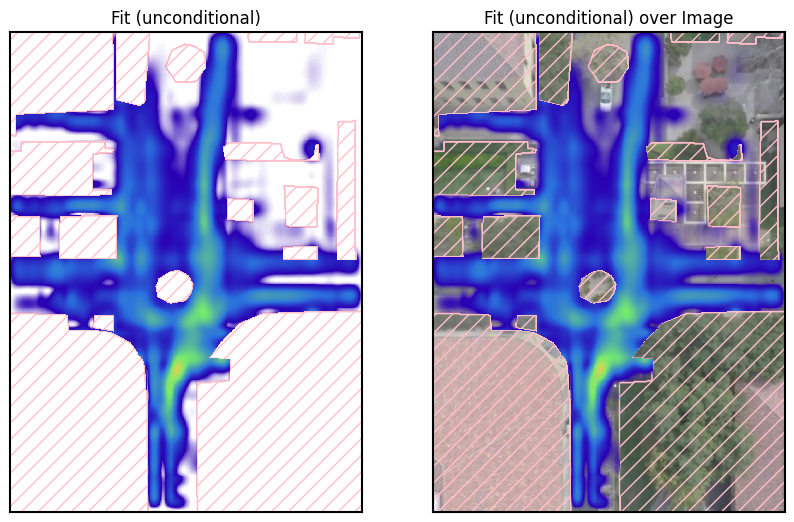

In [18]:
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

with torch.no_grad():
    distribution = spline_model()
    densities = distribution.log_dens(mesh.to(device), with_indicator=True).exp().cpu().numpy()
    densities = densities.reshape(mesh_grid[0].shape).T

plt_extent = [0, img_extent[1], img_extent[3], 0]


fig, axs = plt.subplots(1, 2, figsize=(10, 10))
ax = axs[0]
norm = Normalize(vmin=0, vmax=0.275)
plot_helper.plot_diverging(
    the_ax=ax,
    data=densities,
    valid=valid,
    border=border.T,
    img_extent=plt_extent,
    with_contour=True,
    with_valid=False,
    hatched=True,
    plot_borders_below=True,
    the_cmap=plot_helper.blue_red6_transparent,
    norm=norm,
)

scale = sdd.dataset.get_scale()

ax.set_title(f"Fit (unconditional)")

ax = axs[1]
ax.imshow(sdd.dataset.image)

plt_extent = [0, sdd.dataset.image.shape[1], sdd.dataset.image.shape[0], 0]

plot_helper.plot_diverging(
    the_ax=ax,
    data=densities,
    valid=valid,
    border=border.T,
    img_extent=plt_extent,
    with_contour=True,
    with_valid=False,
    hatched=True,
    plot_borders_below=True,
    the_cmap=plot_helper.blue_red6_transparent,
    norm=norm,
)

ax.set_title(f"Fit (unconditional) over Image")
# add a black border to the image
# frame a bit thicker
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.savefig(
    os.path.join(data_path, "sdd_unconditional_spline_example.png"),
    bbox_inches='tight',
    dpi=300,
)

plt.show()

In [17]:
constraints = sdd.create_constraints()

# y_pos_dict = {i: name for name, i in var_dict.items()}
# plot the fitted polynomial
limits = constraints.get_global_limits()
densities.mean()*((limits['yw'][1] - limits['yw'][0]) * (limits['yh'][1] - limits['yh'][0]))

np.float32(0.99574095)